<div style="border:4px solid red">

For all homework blocks that have numerical answers, name the variable the hw plus the homework number.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import special

# Review

The Sommerfeld diffraction integral is

$E(P_o) = \frac{z}{j\lambda} \int_{\Sigma} E_{inc} \frac{e^{jkr_{01}}}{r_{01}^2} dx' dy'$


The Fresnel diffraction equation is

$E(x,y,z) = \frac{e^{jkz}}{j\lambda z} 
\iint_{\Sigma} E(x',y') 
\exp\left[j\frac{k}{2z}\left((x-x')^2 + (y-y')^2\right)\right]
dx' dy'$


The Fresnel diffraction at focus of lens

$E(x,y,z) = \iint_{\Sigma} E_o(x',y')  
\exp \left( -j\frac{2 \pi}{ \lambda \, f} \left(x \, x' \right) \right) dx' \exp \left( -j\frac{2 \pi}{ \lambda \, f} \left(y \, y' \right) \right) dx' dy'$


Thus, at the focus of the lens the diffraction pattern can be solved using Fourier transforms with the relationships of

$f_x = \frac{x}{\lambda f}, \quad f_y = \frac{y}{\lambda f}$


The Fraunhoffer diffraction equation is 

$E(x,y,z) =
\frac{e^{jkz}}{j\lambda z} e^{j\frac{k}{2z}(x^2+y^2)}
\iint_{\Sigma} E(x',y')
\exp\left[-j\frac{k}{z}(xx' + yy')\right] dx' dy'$

$E(x,y,z) = \left( \mathcal{F}_x \{ E(x') \} \right) \left( \mathcal{F}_y \{ E(y') \} \right)$

with $f_x=\frac{x}{\lambda z}$ and $f_y=\frac{y}{\lambda z}$

## Basic Fourier Transform Relations

<details open>
<summary>Click to collapse</summary>

If $f(x) \leftrightarrow F(f)$:

-   $K f(x) \leftrightarrow K F(f)$
-   $f(ax) \leftrightarrow \frac{1}{|a|} F\!\left(\frac{f}{a}\right)$
-   $f(x-x_0) \leftrightarrow F(f)e^{-j2\pi f x_0}$
-   $e^{j2\pi f_0 x} f(x) \leftrightarrow F(f-f_0)$

</details>

## Fourier Transform Pairs
<details open>
<summary>Click to collapse</summary>

| Function | Fourier Transform |
|-----------|------------------|
| $\delta(x)$ | $1$ |
| $A$ | $2\pi A\,\delta(f)$ |
| $\cos(\omega_0 x)$ | $\pi[\delta(f-\omega_0)+\delta(f+\omega_0)]$ |
| $\sin(\omega_0 x)$ | $j\pi[\delta(f-\omega_0)-\delta(f+\omega_0)]$ |
| $\text{rect}(x)$ | $\text{sinc}(f)$ |
| $\Lambda(x)$ | $\text{sinc}^2(f)$ |
| $\text{circ}(r/R)$ | $\pi R^2 \dfrac{J_1(2\pi R f)}{2\pi R f}$ |
| $e^{-\pi x^2}$ | $e^{-\pi f^2}$ |
| $e^{j\pi x^2}$ | $e^{j\pi/4} e^{-j\pi f^2}$ |
| $\sum_{n=-S}^{S}\delta(x-n)$ | $\dfrac{\sin(M\pi f)}{\sin(\pi f)}$, $M=2S+1$ |
| $\sum_{n=-\infty}^{\infty}\delta(x-n)$ | $\sum_{n=-\infty}^{\infty}\delta(f-n)$ |


$\text{rect}(x) = \begin{cases}
1 & |x| \le \frac{1}{2} \\
0 & \text{otherwise}
\end{cases}$

$\text{sinc}(x)=\frac{\sin (\pi x)}{\pi x}$

$\Lambda(x) = \begin{cases}
1-|x| & |x| \le 1 \\
0 & \text{otherwise}
\end{cases}$

$\text{circ}\left(\sqrt{x^2 + y^2}\right) = \begin{cases}
1 & \sqrt{x^2 + y^2} \le 1 \\
0 & \text{otherwise}
\end{cases}$

$\int_{-\infty}^{\infty} \mathrm{sinc}(x)\, dx = 1$

$\int_{-\infty}^{\infty} \mathrm{sinc}^2(x)\, dx = 1$

$\int_{0}^{\infty} \left| \frac{J_1(x)}{x} \right|^2 dx = \frac{4}{3\pi}$

$\int_{0}^{\infty} x \left| \frac{J_1(x)}{x} \right|^2 dx = \frac{1}{2}$

</details>

<div style="border:4px solid red">

**HW1:** A plane wave is incident onto an aperture that consists of two separated square apertures.  The separation of the squares is $D$ and the width of the squares is $W$.  Imediately after the aperture is an ideal lens with a focal length of $f$.

<img src="double_slit.png" width="200">

Derive the analytic solution of the diffraction pattern at the plane $z=f$. With wavelength $\lambda=600nm$, and width of $W=10mm$. Create a line profile pot in the x-direction.  Adjust the aperture spacing to see that the spacing creates fringes in the x-direction.  What aperture spacing in units of meters creates  diffraction pattern with fringe spacing of $2 \mu m$.



## 1. Problem setup and notation

- Aperture plane coordinates: $(x',y')$.
- Focal (observation) plane coordinates: $(x,y)$ at $z=f$.

Let the two identical square apertures each have width $W$ and centers separated along the $x'$-axis by distance $D$. The lens of focal length $f$ is placed immediately after the aperture; evaluation plane is the focal plane $z=f$ (Fraunhofer via lens).

## 2. Aperture transmission using rect

Place two squares centered at $x'=\pm D/2$ (same $y'$ location). The transmission function of the whole pupil is

$E(x',y') = E_o \, \operatorname{rect}\!\Big(\frac{x'+D/2}{W}\Big)\operatorname{rect}\!\Big(\frac{y'}{W}\Big)\;+\;
\operatorname{rect}\!\Big(\frac{x'-D/2}{W}\Big)\operatorname{rect}\!\Big(\frac{y'}{W}\Big).$


## 3. Fourier transform
This has two Fourier transform relations 

Time shift: $f(x') = f(x'-x_o)$ with $x_o=\pm D/2$

Scaling: $f(x')=f(a \, x')$ with $a=\frac{1}{W}$


The 1D Fourier transform (spatial) of $\operatorname{rect}\!\big(\dfrac{x'}{W}\big)$ is

$\mathcal{F}\left\{\operatorname{rect}\!\Big(\frac{x'}{W}\Big)\right\}
= W\,\operatorname{sinc}\!\Big(\frac{f_x W}{2}\Big),$

where $\operatorname{sinc}(u)=\dfrac{\sin u}{u}$. 

Because the square aperture is separable in $x'$ and $y'$, the 2D FT of a single square of width $W$ centered at the origin is

$\mathcal{F}\big\{\operatorname{rect}(x'/W)\operatorname{rect}(y'/W)\big\} = 
W^2\,\operatorname{sinc}\!\Big(\frac{f_x W}{2}\Big)\operatorname{sinc}\!\Big(\frac{f_y W}{2}\Big).$


If $g(x')$ has Fourier transform $G(f_x)$, then $g(x'-x_o)$ has Fourier transform of $e^{-j f_x x_o} \, G(f_x)$. Apply this to each shifted square:

- Left square (center $x'=-D/2$) contributes factor $e^{+j f_x D/2}$ times the centered-square FT.
- Right square (center $x'=+D/2$) contributes factor $e^{-j f_x D/2}$ times the centered-square FT.

Therefore the total pupil FT is the sum:
\begin{align*}
\mathcal{F}\{E\}(f_x,f_y)
&= W^2\,\operatorname{sinc}\!\Big(\frac{f_x W}{2}\Big)\operatorname{sinc}\!\Big(\frac{f_y W}{2}\Big)\;\big(e^{+j f_x D/2} + e^{-j f_x D/2}\big)\\[6pt]
&= 2W^2\,\operatorname{sinc}\!\Big(\frac{f_x W}{2}\Big)\operatorname{sinc}\!\Big(\frac{f_y W}{2}\Big)\;\cos\!\Big(\frac{f_x D}{2}\Big).
\end{align*}

This identity $(e^{j\alpha}+e^{-j\alpha})=2\cos\alpha$ is where the cosine factor originates.

$I(x,y) = I_0\;
\operatorname{sinc}^2\!\Big(\frac{W x}{\lambda f}\Big)\;
\operatorname{sinc}^2\!\Big(\frac{W y}{\lambda f}\Big)\;
\cos^2\!\Big(\frac{D x}{\lambda f}\Big),$

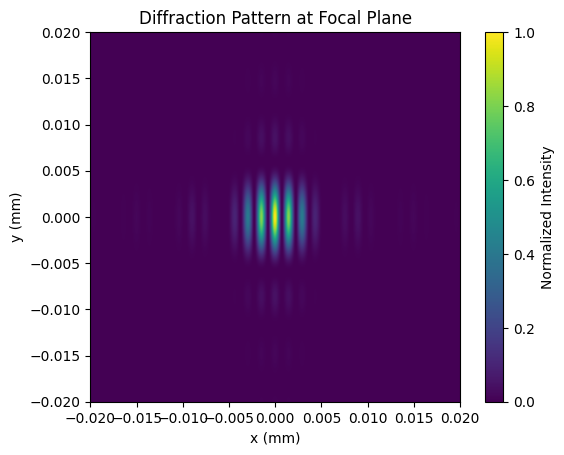

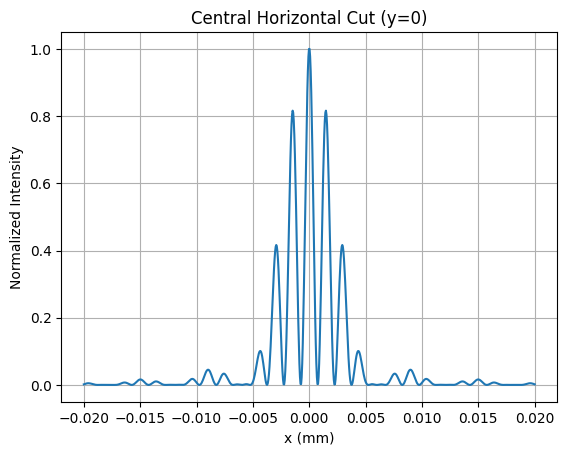

Fringe spacing (um): 1.4999999999999998
Main lobe width (um): 5.999999999999999


In [ ]:
#CODE For HW1

# -----------------------------
# Parameters
# -----------------------------
wavelength = 600e-9   # 600 nm
D = 80e-3              # 1 mm separation
W = 20e-3             # 10 mm width
f = 0.20              # focal length (meters) → change if needed
Eo = 1.0              # field amplitude

# -----------------------------
# Grid (focal plane)
# -----------------------------
x_max = .02e-3   # .04 mm range
y_max = .02e-3
N = 800

x = np.linspace(-x_max, x_max, N)
y = np.linspace(-y_max, y_max, N)
X, Y = np.meshgrid(x, y)


# Gratings

We now extend a single aperture into a periodic array. A grating is easiest to analyze as three separate pieces.

<img src="grating.jpg" width="500">

Grating parameters:
1. The period of the grating is the spacing between repeated apertures and is $\Lambda$.
2. The width of one aperture is set by the fill factor $F$, so the aperture width is $F\Lambda$ with $0<F<1$.
3. The total finite grating occupies an outer region of size $W_x\times W_y$.

## Three-Part Construction of a Finite Grating

### 1. Single aperture

Start with one aperture inside one unit cell. In 1D,

$$a(x)=\operatorname{rect}\!\left(\frac{x}{F\Lambda}\right).$$

### 2. Infinite replication with delta functions

Replicate the aperture periodically by convolving it with an infinite set of delta functions.  The infinite set of delta functions is called a comb function.

The comb function is 

$$comb \left( x \right) =\sum_{n=-\infty}^{\infty}\delta(x-n)$$

$$b(x) = comb \left( \frac{x}{\Lambda}\right) 
=\sum_{n=-\infty}^{\infty}\delta(\frac{x}{\Lambda}-n) 
\approx \sum_{n=-\infty}^{\infty}\delta(x-n \Lambda)  $$

Convolving these two function is 

$$T(x)=a(x) \otimes b(x)$$

which becomes

$$T(x) = \left( \operatorname{rect}\!\left(\frac{x}{F\Lambda}\right) \right)
\otimes
\sum_{m=-\infty}^{\infty}\delta(x-m\Lambda).
$$

Let's review convolution

$$f \otimes g = \int_{-\infty}^{\infty} f(\tau) g(x-\tau) d \tau$$

Setting up intergral for $T(x)$ (use $\tau$ for $x$ in the rect function and $x-\tau$ in the comb function) results in 

$$T(x) = \sum_{m=-\infty}^{\infty} \int_{-\infty}^{\infty} \operatorname{rect}\!\left(\frac{\tau}{F\Lambda}\right) 
\delta(x-\tau-m\Lambda) \, d \tau
$$

The intergral with a delta function results in just evaluating the integral at the zero of the delta function resulting in 
$x-\tau-m\Lambda=0$ or $\tau = x - m \Lambda$

The integral becomes

$$T(x) = \sum_{m=-\infty}^{\infty} \operatorname{rect}\!\left(\frac{x - m \Lambda}{F\Lambda}\right)$$

which is an infinite set of rect functions separated by $\Lambda$


### 3. Outer aperture defining the finite size

A real grating is not infinite, so multiply by an outer window that keeps only the illuminated or fabricated region.

$$
c(x,y)=\operatorname{rect}\!\left(\frac{x}{W_x}\right)\operatorname{rect}\!\left(\frac{y}{W_y}\right).
$$

The actual electric field is therefore

$$E(x,y)=E_o \, T(x,y)= E_o \, \left[ a(x,y) \otimes b(x,y) \right] c(x,y)$$

Taking the Fourier transform gives

$$
E(f_x,f_y)=E_o \, \left[A(f_x,f_y) B(f_x f_y) \right] \otimes C(f_x,f_y).
$$

# Fourier Transform of a 1D Finite Grating with Slit Apertures

## Step 1: Fourier Transform Setup

Using:

- Convolution theorem: $\mathcal{F}\{f \otimes g\} = F \cdot G$
- Multiplication theorem: $\mathcal{F}\{fg\} = F \otimes G$

we get:

$E(f_x) = \big(A(f_x)\, B(f_x)\big) \otimes C(f_x)$

---

## Step 2: Individual Transforms

### Single slit

$a(x) = \mathrm{rect}\left(\frac{x}{F\Lambda}\right)$

$A(f_x) = F\Lambda \, \mathrm{sinc}(F\Lambda f_x)$


### Comb function

$b(x) = \mathrm{comb}\left(\frac{x}{\Lambda}\right)$

$B(f_x) = \frac{1}{\Lambda} \mathrm{comb}(\Lambda \, f_x)$


### Finite width

$c(x) = \mathrm{rect}\left(\frac{x}{W_x}\right)$

$C(f_x) = W_x \, \mathrm{sinc}(W_x \, f_x)$


## Step 3: Combine Results

Multiply first:

$A(f_x) B(f_x) = F \, \mathrm{sinc}(F\Lambda f_x)\, \mathrm{comb}(\Lambda f_x)$

Convolution with outer aperture and dropping common amplitude term

$E(f_x) = \left[\mathrm{sinc}(F\Lambda f_x)\, \mathrm{comb}(\Lambda f_x) \right] \otimes \left[ W_x \, \mathrm{sinc}(W_x f_x) \right]$

Plug in the definition for the comb function.

$E(f_x) = \left[ \mathrm{sinc}(F\Lambda f_x) \, \sum_{m=-\infty}^{\infty}   \delta(\Lambda \, f_x - m) \right] \otimes \left[ W_x \, \mathrm{sinc}(W_x f_x) \right]$

$E(f_x) = \left[ \sum_{m=-\infty}^{\infty} \mathrm{sinc}(F\Lambda f_x) \,    \delta(\Lambda \, f_x - m) \right] \otimes \left[ W_x \, \mathrm{sinc}(W_x f_x) \right]$

Change the argument of the delta function.  (Remember that this changes the amplitude when it is integrated but we have been neglecting the amplitue terms, so this doesn't matter.)

$E(f_x) = \left[ \sum_{m=-\infty}^{\infty} \mathrm{sinc}(F\Lambda f_x) \,    \delta(f_x - \frac{m}{\Lambda}) \right] \otimes \left[ W_x \, \mathrm{sinc}(W_x f_x) \right]$



Write the convolution integral

$E(f_x)=
\int_{-\infty}^{\infty}
\left[
F\,\mathrm{sinc}(F\Lambda \tau)\,
\sum_{m=-\infty}^{\infty}\delta\!\left(\tau-\frac{m}{\Lambda}\right)
\right]
\left[
W_x\,\mathrm{sinc}\big(W_x(f_x-\tau)\big)
\right]
\, d\tau$

Since the integral has delta functions, the convolution is simply evaluating the function at the zero of the delta function 

$\tau=\frac{m}{\Lambda}$

resulting in 

$E(f_x) = \sum_{m=-\infty}^{\infty} \mathrm{sinc}(F\Lambda \frac{m}{\Lambda})\, \mathrm{sinc}\big(W_x (f_x - \frac{m}{\Lambda})\big)$

$E(f_x) = \sum_{m=-\infty}^{\infty} \mathrm{sinc}(F \, m)\, \mathrm{sinc}\big(W_x (f_x - \frac{m}{\Lambda})\big)$

The final result is to plug in for $f_x$.  

$f_x=\frac{x}{\lambda \, z}$ or with a lens it becomes $f_x=\frac{x}{\lambda \, f}$ 

$E(x, z) = \sum_{m=-\infty}^{\infty} \mathrm{sinc}(F \, m)\, \mathrm{sinc}\big(W_x (\frac{x}{\lambda \, z} - \frac{m}{\Lambda})\big)$



## Interpretation

There are a set of sinc function centered at $\frac{x}{\lambda \, z} - \frac{m}{\Lambda}=0$ or $x =m \frac{\lambda \, z}{\Lambda}=0$.

These different beams are called diffractive orders.  

The term $\mathrm{sinc}(F \, m)$ determines how much power is in each order.  This is called the efficiency.

1. $\frac{\lambda}{\Lambda}$ determine the direction of the grating order.
2. $W$ determines the shape of the diffracted order.
3. The single period determines the efficiency of each order.



<div style="border:4px solid red">

**HW2:** A binary amplitude grating (i.e. aperture grating) has a width of $5\mu m$, and a period of $\Lambda=10 \mu m$.  Both of these are in the x-direction. The slits are infinite in the y-direction. What is the fill factor?

<div style="border:4px solid red">

**HW3:** A binary amplitude grating (i.e. aperture grating) has a width of $5\mu m$, a period of $\Lambda=10 \mu m$. Both of these are in the x-direction. The grating aperture is illuminated by green light that has a wavelength of $\lambda=515nm$.  The grating has a square size of 1mm x 1mm.  The green light has a uniform irradiance across the grating. What is the angle in degrees between the m=0 beam and the m=1 beam? 

# Derivation of the Grating Equation from the Far-Field Grating Sum

We start from the far-field field distribution

$$
E(x, z) = \sum_{m=-\infty}^{\infty}
\mathrm{sinc}(F m)\,
\mathrm{sinc}\!\left(W_x\left(\frac{x}{\lambda z}-\frac{m}{\Lambda}\right)\right).
$$

Here:

- $\Lambda$ is the grating period,
- $F\Lambda$ is the slit width,
- $W_x$ is the total finite width of the grating,
- $z$ is the observation distance,
- $x$ is the transverse coordinate in the observation plane.

The second sinc term is centered when

$$
\frac{x}{\lambda z} = \frac{m}{\Lambda}.
$$

So the dominant maxima occur at

$$
x_m = \frac{m\lambda z}{\Lambda}.
$$

## 1. From screen position to diffraction angle

In the far field,

$$
\tan\theta_m = \frac{x_m}{z}.
$$

For small angles,

$$
\tan\theta_m \approx \sin\theta_m \approx \frac{x_m}{z}.
$$

Substituting the peak position gives

$$
\sin\theta_m \approx \frac{m\lambda}{\Lambda}.
$$

Thus, for normal incidence, the grating equation is

$$
\Lambda \sin\theta_m = m\lambda.
$$

## 2. Physical meaning

The field is a finite-slit diffraction envelope multiplied by a discrete set of peaks. The peak locations come from the argument of the second sinc function, which is largest when its argument vanishes:

$$
\frac{x}{\lambda z} - \frac{m}{\Lambda} = 0.
$$

That is the far-field statement of constructive interference between adjacent slits.

## 3. Generalization to non-normal incidence

If the incident wave arrives at an angle $\theta_i$, the incident wavefront already introduces a phase difference between neighboring slits. For a transmission grating, the path difference between adjacent slits is

$$
\Lambda\left(\sin\theta_m - \sin\theta_i\right).
$$

Constructive interference occurs when this equals an integer number of wavelengths:

$$
\Lambda\left(\sin\theta_m - \sin\theta_i\right) = m\lambda.
$$

Equivalently,

$$
\sin\theta_m = \sin\theta_i + m\frac{\lambda}{\Lambda}.
$$



<div style="border:4px solid red">

**HW4:** A binary amplitude grating (i.e. aperture grating) has $1200$ lines/mm and is used at normal incidence with a HeNe laser at $\lambda=632.8\text{ nm}$. What is the first-order diffraction angle in degrees? Name it `hw3`.

<div style="border:4px solid red">

**HW5:** A binary amplitude grating (i.e. aperture grating) is designed to divide an incident green laser with a wavelength of  $\lambda=515\text{ nm}$. The grating is followed by a microscope objective that is modeled as an ideal lens with a focal length of $f=20mm$.  At the focus of the lens ($z=20mm$) what grating period, produces beams separated by $0.01mm$?  Name it hw6.  Use units of meters.

<div style="border:4px solid red">

**HW6:** A plane wave with wavelength $\lambda=600\text{ nm}$ is incident onto an aperture that consists of a periodic set of circular holes.

<img src="grid.jpg" width="500">

The aperture consists of a $10\times10$ array of holes with diameter $10\ \mu\text{m}$ and spacing $20\ \mu\text{m}$. The aperture is followed by a lens with focal length $f=10\text{ mm}$.

Plot the normalized electric-field magnitude and normalized irradiance at the lens focus. What is the spacing between the  grating orders in the center (m=0) and the focal plane? Name it hw10.

hw5 = 0.12656 nm


<div style="border:4px solid red">

**HW7:** With the previous problem, what is the fraction of power in the center beam? 